In [1]:
#data manipulation
import numpy as np
import pandas as pd

#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import bokeh as bk
%matplotlib inline

#consistent sized plots
from pylab import rcParams
rcParams['figure.figsize'] = 12,5
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['axes.titlesize'] = 14

#handle warnings
import warnings
warnings.filterwarnings(action='ignore',category=DeprecationWarning)
warnings.filterwarnings(action='ignore',category=FutureWarning)

#view all the columns in the dataframe
pd.options.display.max_columns = None

# Time-series manipulation
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from pandas import Series

# ARIMA
!pip install pmdarima > /dev/null
import pmdarima as pm

In [2]:
df = pd.read_excel("data_barbershop.xlsx")
df.head()

,Tanggal,cust_count,cust_unique,cust_old_count,cust_new_count,day_name,weekend_or_holiday,cash_count,qris_count,haircut_count,haircut_total,payment_total
0,2021-08-16,3.0,3.0,3.0,0.0,Saturday,True,3.0,0.0,3.0,90000.0,90000.0
1,2021-08-17,5.0,5.0,5.0,0.0,Sunday,True,5.0,0.0,5.0,150000.0,150000.0
2,2021-08-18,5.0,5.0,4.0,1.0,Monday,False,5.0,0.0,5.0,150000.0,150000.0
3,2021-08-19,3.0,3.0,3.0,0.0,Tuesday,False,3.0,0.0,3.0,90000.0,90000.0
4,2021-08-21,11.0,11.0,11.0,0.0,Friday,False,11.0,0.0,11.0,330000.0,330000.0


In [3]:
# change columns Month to datetime
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

# set Tanggal as index
df.set_index("Tanggal", inplace=True)
df.head()

,cust_count,cust_unique,cust_old_count,cust_new_count,day_name,weekend_or_holiday,cash_count,qris_count,haircut_count,haircut_total,payment_total
Tanggal,,,,,,,,,,,
2021-08-16,3.0,3.0,3.0,0.0,Saturday,True,3.0,0.0,3.0,90000.0,90000.0
2021-08-17,5.0,5.0,5.0,0.0,Sunday,True,5.0,0.0,5.0,150000.0,150000.0
2021-08-18,5.0,5.0,4.0,1.0,Monday,False,5.0,0.0,5.0,150000.0,150000.0
2021-08-19,3.0,3.0,3.0,0.0,Tuesday,False,3.0,0.0,3.0,90000.0,90000.0
2021-08-21,11.0,11.0,11.0,0.0,Friday,False,11.0,0.0,11.0,330000.0,330000.0


In [5]:
data=df[['cust_count','cust_unique']]
data

,cust_count,cust_unique
Tanggal,,
2021-08-16,3.0,3.0
2021-08-17,5.0,5.0
2021-08-18,5.0,5.0
2021-08-19,3.0,3.0
2021-08-21,11.0,11.0
...,...,...
2022-03-27,13.0,13.0
2022-03-28,16.0,16.0
2022-03-29,8.0,8.0


In [7]:
# cek missing value
data.isnull().sum()

cust_count     3
cust_unique    3
dtype: int64

In [8]:
# fill missing value mean/media
data['cust_count'].fillna(int(data['cust_count'].mean()), inplace=True)
data['cust_unique'].fillna(int(data['cust_unique'].mean()), inplace=True)

/usr/local/lib/python3.8/dist-packages/pandas/core/generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [11]:
df.duplicated().sum()

8

In [13]:
# Bagi data train dan test
# Data test untuk 3 t kedepan

split_data = len(data) - 23
train_data = data[:split_data]
test_data = data[split_data:]

print("data train :", len(train_data))
print("data test :", len(test_data))

data train : 201
data test : 23


#Identifikasi Model

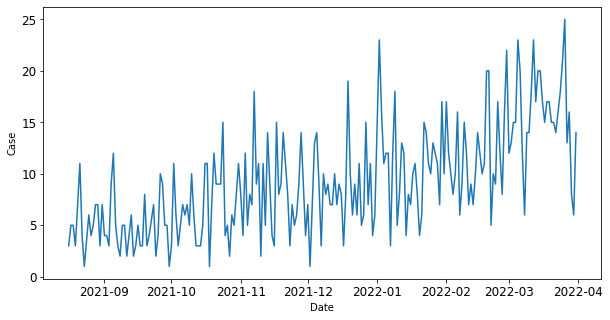

In [14]:
plt.figure(figsize=(10,5))
plt.xlabel('Date')
plt.ylabel('Case')
plt.plot(data['cust_unique'])